# Chronos-2 Quality Net — Results, prediction_length=4, context_length=512 (2026-08-18)

`train/finetune_chronos2.py --prediction-length 4`, `eval/backtest.py`로 실행한 결과입니다.
`context_length`은 `results.ipynb`와 동일하게 512(기본값)로 고정하고, **prediction_length만 1(기존) →
4(신규)로 바꿨습니다** — 두 노트북을 나란히 열어서 비교하면 됩니다. (참고: `results_context24.ipynb`는
반대로 prediction_length=1을 고정하고 context_length만 24로 바꾼 별도 실험입니다.)

prediction_length=4로 바꾼 이유: blaine/residue 실측치는 `QUALITY_MEASUREMENT_HOURS = [0,4,8,12,16,20]`,
즉 정확히 4시간 간격으로만 존재하고 나머지 시간은 NaN입니다. `chronos/chronos2/dataset.py`의 학습 샘플링은
전체 시계열에서 완전히 랜덤한 시점을 뽑아 그 다음 `prediction_length`시간을 타깃으로 쓰므로,
prediction_length=1이면 뽑힌 시점의 바로 다음 1시간이 실측 시각일 확률이 25%뿐이라 학습 신호의 상당수가
낭비됩니다. prediction_length=4로 늘리면 4시간 간격 grid 특성상 어떤 4시간 구간을 뽑아도 반드시 실측
시각이 하나 포함되어 학습 신호 밀도가 개선될 것이라는 가설을 검증한 실험입니다.

이 노트북은 GPU를 다시 쓰지 않습니다 — `eval/backtest_*_predlen4_*.csv` 결과 파일(과 prediction_length과
무관한 기존 zero-shot 결과 파일)만 읽습니다. 평가 자체는 기존 `eval/backtest.py`를 그대로 썼습니다
(`predict_df`의 `prediction_length=1`은 하드코딩돼 있는데, chronos-2는 학습 때보다 짧은 prediction_length로
추론해도 문제없어서, "1-step 예측을 얼마나 잘하는가"라는 잣대는 `results.ipynb`와 동일하게 유지됩니다 —
바뀐 건 오직 학습 시 held-out 구간 길이뿐입니다).

비교 대상 4가지:
- **Naive baseline**: 직전 실측값을 그대로 예측값으로 사용
- **Zero-shot**: `amazon/chronos-2` 사전학습 가중치, 파인튜닝 없음 (prediction_length과 무관 — `results.ipynb`와 같은 파일 재사용)
- **LoRA**: `--prediction-length 4 --context-length 512`로 학습 (`checkpoints/{target}_predlen4/final`)
- **Full fine-tuning**: `--prediction-length 4 --context-length 512`, `learning_rate=1e-6` (`checkpoints/{target}_full_predlen4/final`)

In [1]:
import sys
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib

plt.rcParams['font.family'] = 'Malgun Gothic'  # Windows 한글 폰트
matplotlib.rcParams['axes.unicode_minus'] = False

ROOT = Path.cwd()
if not (ROOT / "config.py").exists():
    raise RuntimeError(
        f"config.py를 {ROOT} 에서 찾지 못했습니다. Jupyter를 chronos_quality_net 폴더에서 실행하거나, "
        "이 노트북을 그 폴더로 옮겨서 다시 여세요."
    )
sys.path.insert(0, str(ROOT))
import config as cfg

TARGETS = cfg.TARGET_COLS  # ["blaine", "residue"]
print("targets:", TARGETS)
print("spec ranges:", cfg.SPEC_RANGES)

METHODS = ["zero-shot", "LoRA", "Full fine-tuning"]

# zero-shot은 prediction_length와 무관(파인튜닝 없이 사전학습 가중치 그대로 평가)하므로
# results.ipynb가 만든 기존 backtest_*_zeroshot.csv를 그대로 재사용합니다.
# blaine 파일명만 대문자(BLAINE)로 남아있는 건 과거 스크립트 잔재라 그대로 둡니다(재생성 안 함).
RESULT_FILES = {
    "blaine": {
        "zero-shot": "backtest_BLAINE_zeroshot.csv",
        "LoRA": "backtest_blaine_predlen4_lora.csv",
        "Full fine-tuning": "backtest_blaine_predlen4_full.csv",
    },
    "residue": {
        "zero-shot": "backtest_residue_zeroshot.csv",
        "LoRA": "backtest_residue_predlen4_lora.csv",
        "Full fine-tuning": "backtest_residue_predlen4_full.csv",
    },
}

targets: ['blaine', 'residue']
spec ranges: {'blaine': (3700.0, 3900.0), 'residue': (7.0, 9.0)}


## 1. 결과 파일 불러오기

In [2]:
EVAL_DIR = ROOT / "eval"

results = {}
for target in TARGETS:
    results[target] = {}
    for method, fname in RESULT_FILES[target].items():
        p = EVAL_DIR / fname
        if p.exists():
            results[target][method] = pd.read_csv(p, parse_dates=["timestamp"])
        else:
            print(f"[missing] {p}")

for target in TARGETS:
    for method in METHODS:
        df = results[target].get(method)
        print(target, method, "->", None if df is None else f"{len(df)} rows")

blaine zero-shot -> 1007 rows
blaine LoRA -> 1007 rows
blaine Full fine-tuning -> 1007 rows
residue zero-shot -> 979 rows
residue LoRA -> 979 rows
residue Full fine-tuning -> 979 rows


## 2. 요약 지표 (MAE / RMSE / R² / Spec 정확도 / 80% 구간 커버리지)

In [3]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, confusion_matrix


def categorize(values, lo, hi):
    return np.where((values >= lo) & (values <= hi), "IN_SPEC", "OUT_OF_SPEC")


def compute_metrics(df: pd.DataFrame, target: str, pred_col: str) -> dict:
    lo, hi = cfg.SPEC_RANGES[target]
    mae = mean_absolute_error(df["actual"], df[pred_col])
    rmse = np.sqrt(mean_squared_error(df["actual"], df[pred_col]))
    r2 = r2_score(df["actual"], df[pred_col])
    actual_cls = categorize(df["actual"].to_numpy(), lo, hi)
    pred_cls = categorize(df[pred_col].to_numpy(), lo, hi)
    spec_accuracy = float((actual_cls == pred_cls).mean())
    row = {"MAE": mae, "RMSE": rmse, "R2": r2, "spec_accuracy": spec_accuracy, "n": len(df)}
    if pred_col == "pred" and "pred_q10" in df.columns and "pred_q90" in df.columns:
        row["interval_coverage"] = float(
            ((df["actual"] >= df["pred_q10"]) & (df["actual"] <= df["pred_q90"])).mean()
        )
    else:
        row["interval_coverage"] = np.nan
    return row


rows = []
for target in TARGETS:
    first_df = next((df for df in results[target].values() if df is not None), None)
    if first_df is not None:
        rows.append({"target": target, "method": "naive", **compute_metrics(first_df, target, "naive_pred")})
    for method in METHODS:
        df = results[target].get(method)
        if df is not None:
            rows.append({"target": target, "method": method, **compute_metrics(df, target, "pred")})

summary = pd.DataFrame(rows).set_index(["target", "method"])
summary.round(4)

MAE     RMSE      R2  spec_accuracy     n  \
target  method                                                            
blaine  naive             63.2075  92.9357  0.3908         0.7259  1007   
        zero-shot         66.4835  90.7461  0.4192         0.7031  1007   
        LoRA              66.3054  90.2122  0.4260         0.7090  1007   
        Full fine-tuning  64.1827  87.9035  0.4550         0.7100  1007   
residue naive              0.4150   0.6203  0.8091         0.8131   979   
        zero-shot          0.4396   0.6071  0.8172         0.7967   979   
        LoRA               0.4396   0.6030  0.8197         0.8039   979   
        Full fine-tuning   0.4298   0.5863  0.8295         0.8110   979   

                          interval_coverage  
target  method                               
blaine  naive                           NaN  
        zero-shot                    0.4101  
        LoRA                         0.4280  
        Full fine-tuning             0.4836  
residue naive                           NaN  
        zero-shot                    0.3963  
        LoRA                         0.4392  
        Full fine-tuning             0.5117

## 3. 방식별 비교 막대그래프 (MAE, RMSE, Spec 정확도)

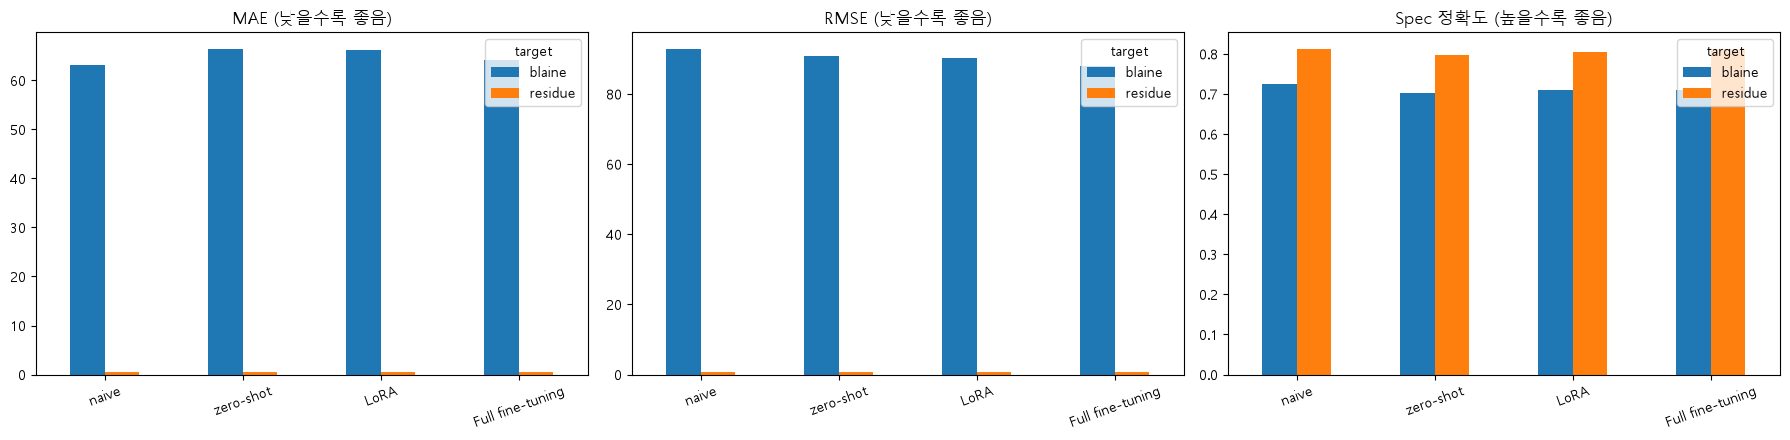

In [4]:
method_order = ["naive"] + METHODS
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

metrics = ["MAE", "RMSE", "spec_accuracy"]
titles = ["MAE (낮을수록 좋음)", "RMSE (낮을수록 좋음)", "Spec 정확도 (높을수록 좋음)"]
for ax, metric, title in zip(axes, metrics, titles):
    plot_df = summary[metric].unstack("target").reindex(method_order)
    plot_df.plot(kind="bar", ax=ax)
    ax.set_title(title)
    ax.set_xlabel("")
    ax.legend(title="target")
    ax.tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

## 4. 실제값 vs 예측값 산점도 (naive / zero-shot / LoRA / full)

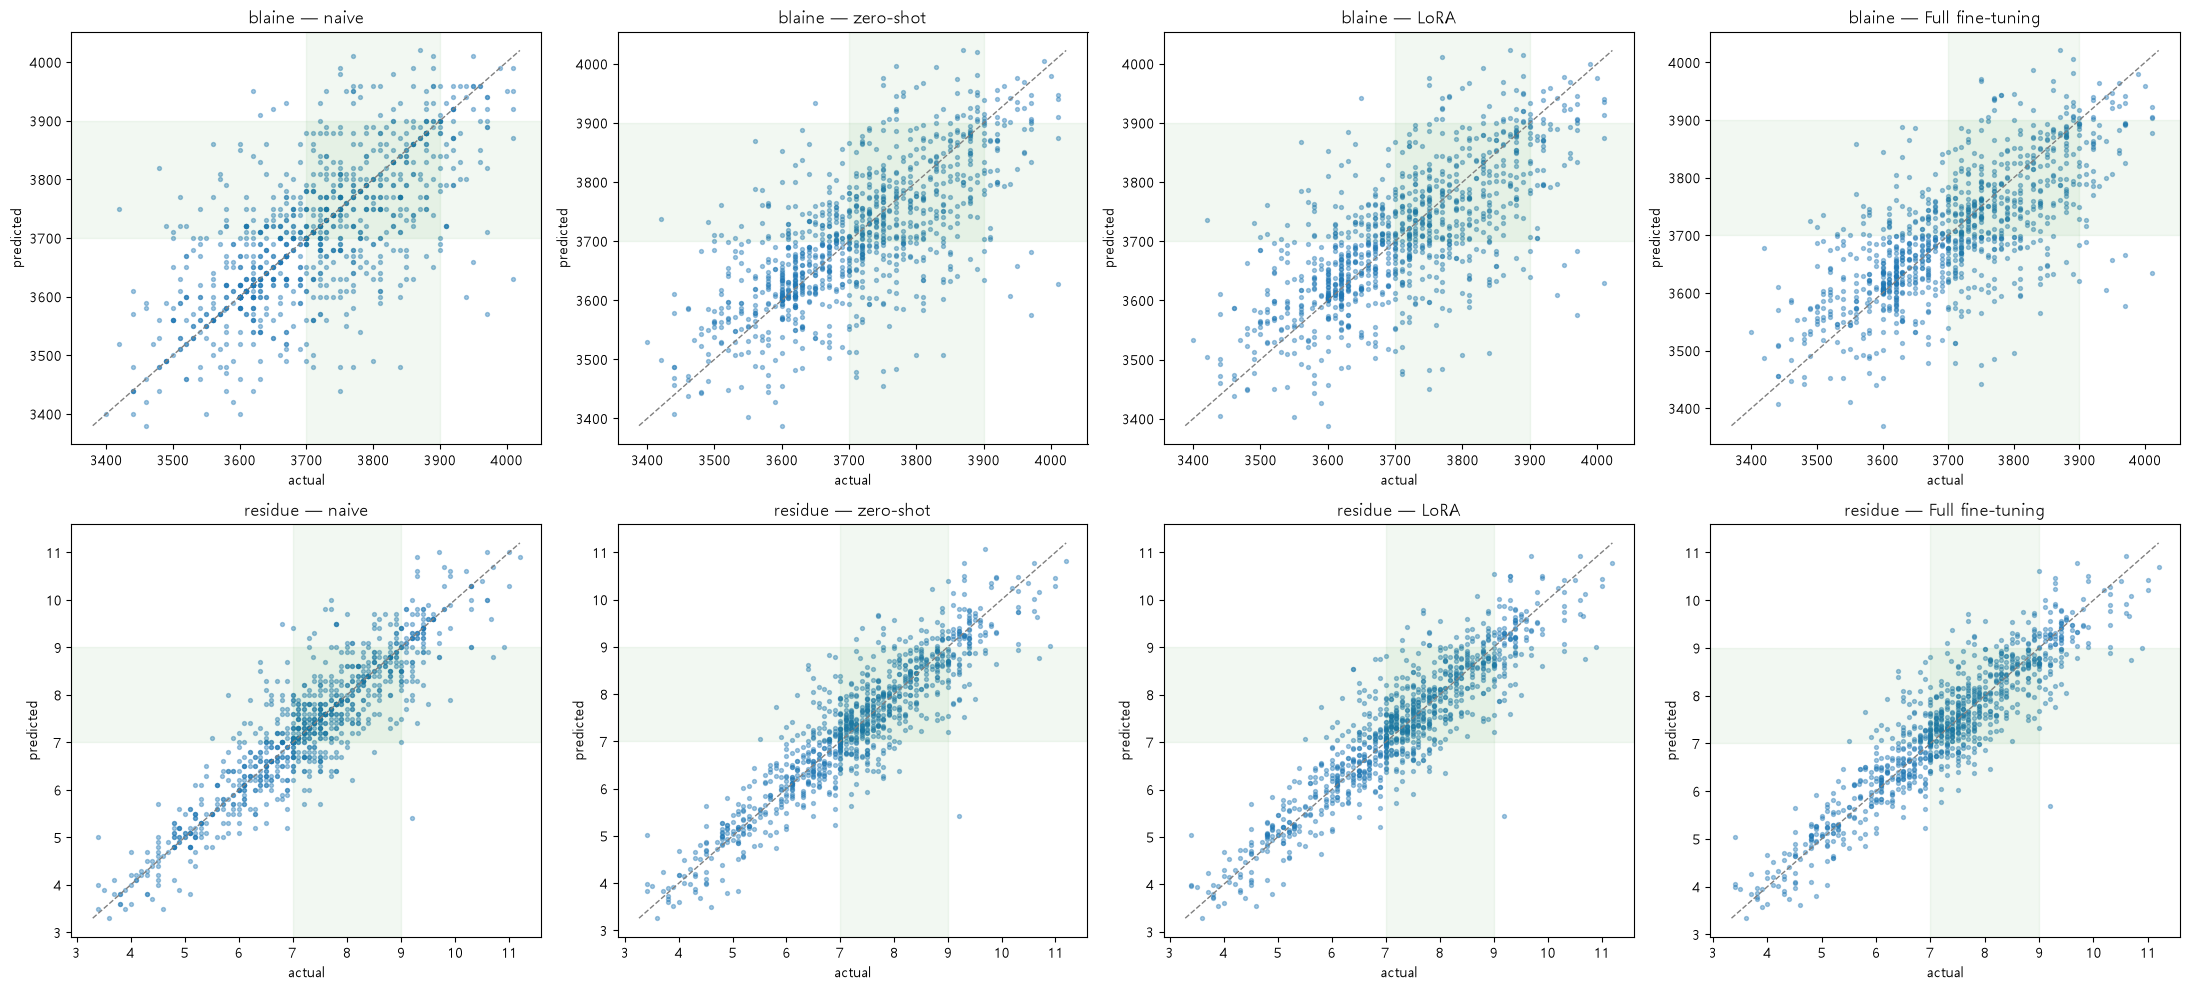

In [5]:
fig, axes = plt.subplots(len(TARGETS), 1 + len(METHODS), figsize=(5.5 * (1 + len(METHODS)), 5 * len(TARGETS)))
if len(TARGETS) == 1:
    axes = axes[None, :]

for row, target in enumerate(TARGETS):
    lo, hi = cfg.SPEC_RANGES[target]
    first_df = next((df for df in results[target].values() if df is not None), None)
    cols = [("naive", "naive_pred", first_df)] + [(m, "pred", results[target].get(m)) for m in METHODS]
    for col_idx, (label, pred_col, df) in enumerate(cols):
        ax = axes[row, col_idx]
        if df is None:
            ax.set_visible(False)
            continue
        ax.scatter(df["actual"], df[pred_col], s=8, alpha=0.4)
        lims = [min(df["actual"].min(), df[pred_col].min()), max(df["actual"].max(), df[pred_col].max())]
        ax.plot(lims, lims, color="gray", linestyle="--", linewidth=1)
        ax.axvspan(lo, hi, color="green", alpha=0.05)
        ax.axhspan(lo, hi, color="green", alpha=0.05)
        ax.set_title(f"{target} — {label}")
        ax.set_xlabel("actual")
        ax.set_ylabel("predicted")

plt.tight_layout()
plt.show()

## 5. 시계열: 실제값 vs 예측 + 80% 예측구간 (full fine-tuning 모델, 호기별)

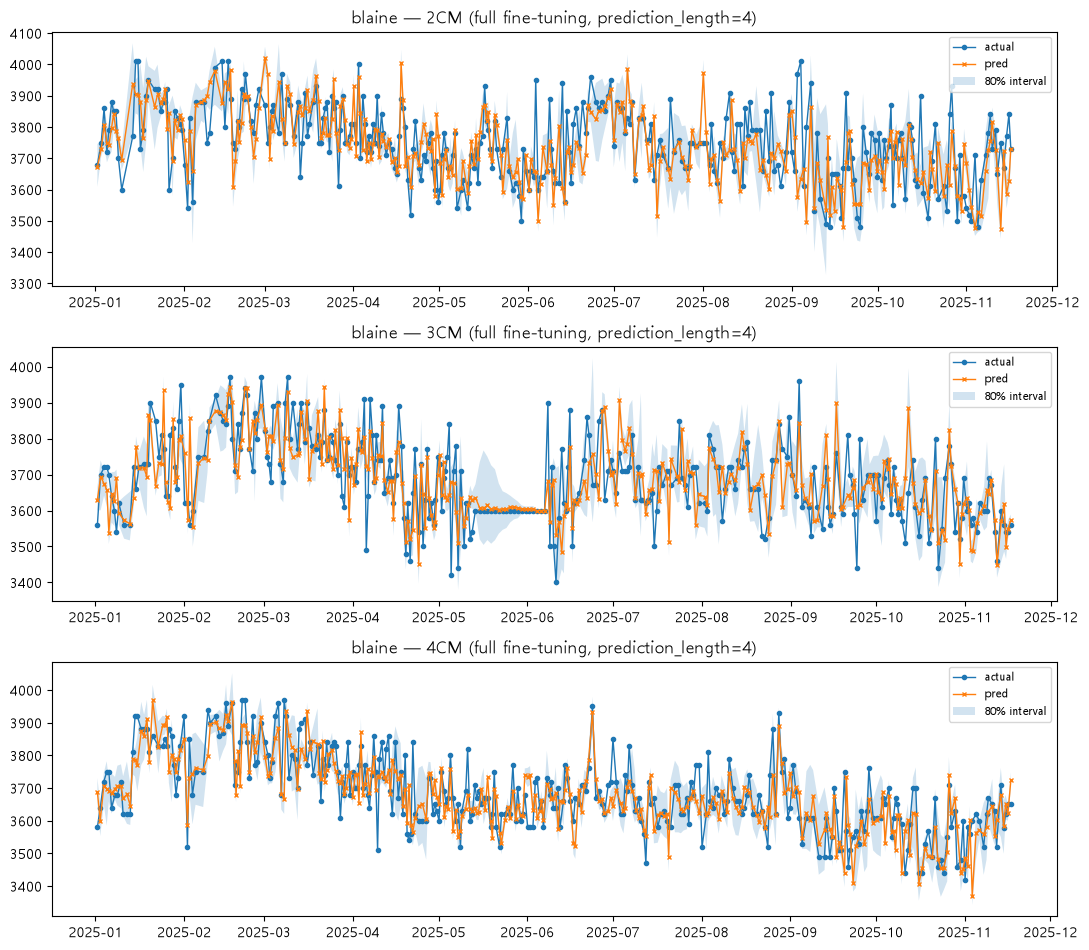

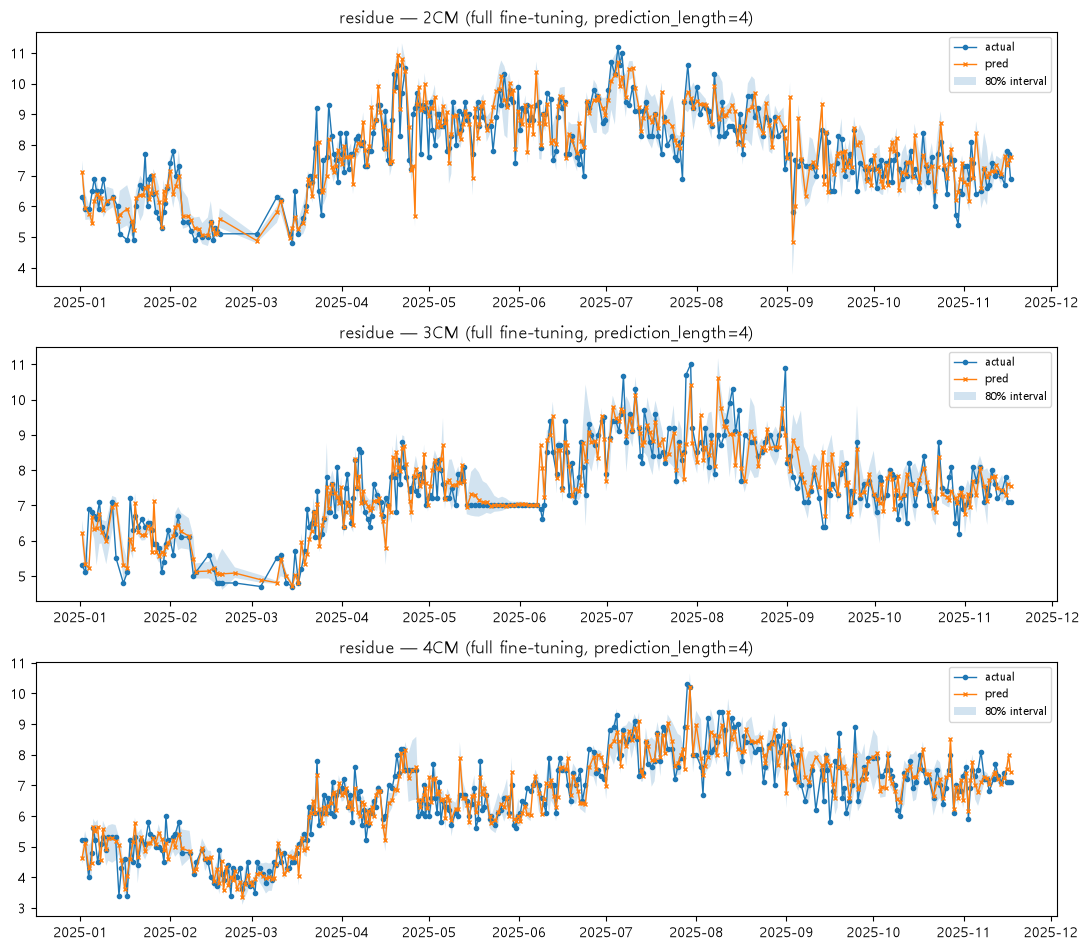

In [6]:
for target in TARGETS:
    df = results[target].get("Full fine-tuning")
    if df is None:
        continue
    item_ids = sorted(df["item_id"].unique())
    fig, axes = plt.subplots(len(item_ids), 1, figsize=(11, 3.2 * len(item_ids)), sharex=False)
    if len(item_ids) == 1:
        axes = [axes]
    for ax, item_id in zip(axes, item_ids):
        g = df[df["item_id"] == item_id].sort_values("timestamp")
        ax.plot(g["timestamp"], g["actual"], label="actual", marker="o", markersize=3, linewidth=1)
        ax.plot(g["timestamp"], g["pred"], label="pred", marker="x", markersize=3, linewidth=1)
        ax.fill_between(g["timestamp"], g["pred_q10"], g["pred_q90"], alpha=0.2, label="80% interval")
        ax.set_title(f"{target} — {item_id} (full fine-tuning, prediction_length=4)")
        ax.legend(loc="upper right", fontsize=8)
    plt.tight_layout()
    plt.show()

## 6. Confusion Matrix (Spec-in / Spec-out)

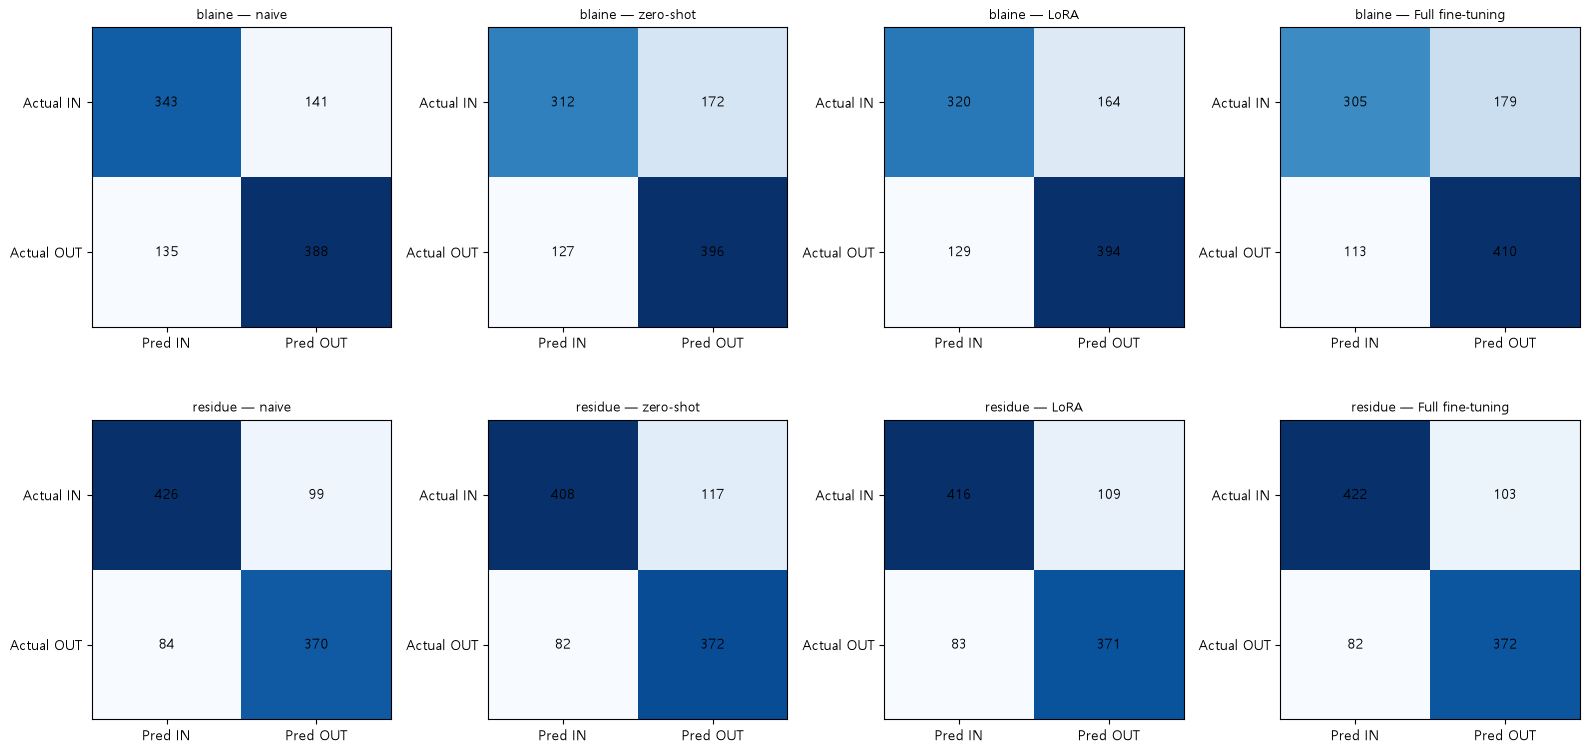

In [7]:
def plot_cm(ax, actual, pred, lo, hi, title):
    actual_cls = categorize(actual, lo, hi)
    pred_cls = categorize(pred, lo, hi)
    cm = confusion_matrix(actual_cls, pred_cls, labels=["IN_SPEC", "OUT_OF_SPEC"])
    ax.imshow(cm, cmap="Blues")
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j], ha="center", va="center")
    ax.set_xticks([0, 1]); ax.set_xticklabels(["Pred IN", "Pred OUT"])
    ax.set_yticks([0, 1]); ax.set_yticklabels(["Actual IN", "Actual OUT"])
    ax.set_title(title, fontsize=9)


fig, axes = plt.subplots(len(TARGETS), 1 + len(METHODS), figsize=(4 * (1 + len(METHODS)), 4 * len(TARGETS)))
if len(TARGETS) == 1:
    axes = axes[None, :]

for row, target in enumerate(TARGETS):
    lo, hi = cfg.SPEC_RANGES[target]
    first_df = next((df for df in results[target].values() if df is not None), None)
    cols = [("naive", "naive_pred", first_df)] + [(m, "pred", results[target].get(m)) for m in METHODS]
    for col_idx, (label, pred_col, df) in enumerate(cols):
        ax = axes[row, col_idx]
        if df is None:
            ax.set_visible(False)
            continue
        plot_cm(ax, df["actual"].to_numpy(), df[pred_col].to_numpy(), lo, hi, f"{target} — {label}")

plt.tight_layout()
plt.show()

## 7. 결론

- **prediction_length을 1(기존)에서 4(신규)로 늘리니 특히 full fine-tuning에서 뚜렷하게 개선됐습니다.**
  blaine MAE는 full 기준 66.24(pred=1) → 64.18(pred=4), R²는 0.4156 → 0.4550으로 개선. residue도
  MAE 0.4370 → 0.4298, R² 0.8222 → 0.8295로 개선됐습니다.
- **LoRA는 효과가 약하거나 혼재** — blaine은 소폭 개선(MAE 66.50→66.31)했지만 residue는 사실상 변화
  없음(MAE 0.4392→0.4396, R²만 미세 개선). LoRA는 학습 가능한 파라미터가 적어서 더 밀도 높은 학습
  신호가 들어와도 그만큼 못 살리는 것으로 보입니다.
- **80% 예측구간 커버리지가 두 타깃·두 방식 모두에서 뚜렷하게 개선**됐습니다 — 특히 full fine-tuning에서
  blaine 41.21%→48.36%(+7.2%p), residue 41.88%→51.17%(+9.3%p). `results_context24.ipynb`까지 포함해
  지금까지 실험 중 가장 큰 커버리지 개선이며, 불확실성 과신 문제가 처음으로 의미 있게 완화됐습니다.
- 다만 **blaine은 여전히 naive baseline(MAE 63.21)을 못 이깁니다** — pred=4 full(64.18)이 가장 근접했지만
  아직 못 넘었습니다. residue는 원래도 naive를 이기고 있었고 pred=4 full로 그 격차가 더 벌어졌습니다.
- 종합하면 **prediction_length=4가 1보다 낫다**고 판단해, 이후 실험은 prediction_length=4로 고정하기로
  결정했습니다. 특히 full fine-tuning + prediction_length=4 조합이 지금까지 실험 중 최고 성능입니다.

prediction_length=1(context_length=512) 결과는 `results.ipynb`, context_length=24 결과는
`results_context24.ipynb` 참고.